<a href="https://www.kaggle.com/code/omborse771924/heatwave-dataset-rajasthan-india-2006-2025-eda?scriptVersionId=328365684" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rupsarroy/heatwave-dataset-rajasthan-india-2006-2025/Rajasthan_Heatwave_2006_2025.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/rupsarroy/heatwave-dataset-rajasthan-india-2006-2025/Rajasthan_Heatwave_2006_2025.csv')

In [3]:
df.head()

,YEAR,MONTH,DAY,WIND_U10,WIND_V10,MSLP,BLH,GEOP,TEMP2M,TMAX,...,RAIN,SRAD,EVAP,SOILT1,SOILM1,LAI,HEATWAVE,LAT,LON,DISTRICT
0,2006,3,1,-0.223022,-0.440903,101036.375,2020.7317,1671.1079,304.75806,303.54395,...,0.0,3117056,-0.000023,312.75903,0.024887,0.515625,0,25.75,71.5,Barmer
1,2006,3,2,-1.344009,-0.294922,101076.440,2265.7910,1671.1079,306.45337,304.95703,...,0.0,3131200,-0.000024,312.66943,0.024345,0.515625,0,25.75,71.5,Barmer
2,2006,3,3,-0.960449,1.522965,101033.750,3152.6023,1671.1079,307.34863,306.21167,...,0.0,3105536,-0.000024,313.12280,0.023773,0.515625,0,25.75,71.5,Barmer
3,2006,3,4,2.704514,1.733017,100896.940,3146.9475,1671.1079,307.43457,306.70508,...,0.0,3126528,-0.000024,314.12085,0.023147,0.515625,0,25.75,71.5,Barmer
4,2006,3,5,2.717834,2.464432,101014.190,2069.5261,1671.1079,306.19507,304.88306,...,0.0,2776448,-0.000041,312.00806,0.027964,0.515625,0,25.75,71.5,Barmer


In [4]:
df.tail()

,YEAR,MONTH,DAY,WIND_U10,WIND_V10,MSLP,BLH,GEOP,TEMP2M,TMAX,...,RAIN,SRAD,EVAP,SOILT1,SOILM1,LAI,HEATWAVE,LAT,LON,DISTRICT
21955,2025,6,26,-2.219376,-1.481064,100094.060,469.85406,1770.1978,305.70264,303.78710,...,2.560620e-04,795008,-0.000177,310.44824,0.145663,0.909058,0,30.0,74.0,Sri Ganganagar
21956,2025,6,27,-1.746262,1.180100,99806.125,1707.57030,1770.1978,309.63060,308.89624,...,5.388260e-04,2091712,-0.000367,309.42920,0.196866,0.915771,0,30.0,74.0,Sri Ganganagar
21957,2025,6,28,-1.339935,1.605103,99605.250,1765.45080,1770.1978,311.13110,309.73510,...,2.720000e-05,2362880,-0.000297,311.01758,0.189011,0.922485,0,30.0,74.0,Sri Ganganagar
21958,2025,6,29,2.582748,1.290008,99331.310,1938.24780,1770.1978,311.31982,310.92578,...,9.540000e-07,2562880,-0.000374,311.30664,0.251657,0.929199,0,30.0,74.0,Sri Ganganagar
21959,2025,6,30,1.378479,2.956360,99488.560,1822.16420,1770.1978,310.76392,310.64722,...,1.000000e-05,2993472,-0.000413,312.24440,0.221453,0.935913,0,30.0,74.0,Sri Ganganagar


In [5]:
df.describe()

,YEAR,MONTH,DAY,WIND_U10,WIND_V10,MSLP,BLH,GEOP,TEMP2M,TMAX,...,CLOUD,RAIN,SRAD,EVAP,SOILT1,SOILM1,LAI,HEATWAVE,LAT,LON
count,21960.000000,21960.000000,21960.000000,21960.000000,21960.000000,21960.000000,21960.000000,21960.000000,21960.000000,21960.000000,...,21960.000000,21960.000000,2.196000e+04,21960.000000,21960.000000,21960.000000,21960.000000,21960.00000,21960.000000,21960.000000
mean,2015.500000,4.491803,15.754098,2.475624,0.723588,100444.274043,2720.154134,2533.205122,310.489501,310.012704,...,0.229915,0.000025,3.018293e+06,-0.000121,314.923305,0.088897,0.705440,0.05000,27.194444,73.666667
std,5.766413,1.118029,8.807157,2.378115,2.603999,528.394425,956.843798,730.211149,4.823235,4.749862,...,0.292535,0.000240,3.899573e+05,0.000119,6.217636,0.074033,0.255386,0.21795,1.352897,1.598647
min,2006.000000,3.000000,1.000000,-9.852875,-10.506165,99062.310000,218.709060,1671.107900,288.333000,289.821780,...,0.000000,0.000000,1.964800e+05,-0.000597,290.145020,-0.003362,0.500000,0.00000,25.250000,71.000000
25%,2010.750000,3.000000,8.000000,0.951839,-1.194061,100032.013750,1967.295925,2038.498500,307.645260,307.107242,...,0.000000,0.000000,2.905536e+06,-0.000176,311.116080,0.025887,0.515625,0.00000,26.250000,73.000000
50%,2015.500000,4.500000,16.000000,2.605873,0.396530,100434.190000,2651.828500,2180.979000,311.434685,311.036625,...,0.110153,0.000000,3.129056e+06,-0.000075,315.802735,0.068370,0.596314,0.00000,27.000000,73.750000
75%,2020.250000,5.000000,23.000000,4.078281,2.403336,100830.265000,3439.665600,2989.502400,313.963740,313.455083,...,0.329498,0.000000,3.265216e+06,-0.000032,319.461490,0.144219,0.857788,0.00000,28.000000,75.000000
max,2025.000000,6.000000,31.000000,11.707886,10.517532,102289.690000,5547.617700,4063.225000,321.840100,320.959960,...,1.000000,0.013919,3.579648e+06,-0.000004,330.317380,0.473269,1.592163,1.00000,30.000000,75.750000


In [6]:
df.isnull()

,YEAR,MONTH,DAY,WIND_U10,WIND_V10,MSLP,BLH,GEOP,TEMP2M,TMAX,...,RAIN,SRAD,EVAP,SOILT1,SOILM1,LAI,HEATWAVE,LAT,LON,DISTRICT
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21955,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
21956,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
21957,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
21958,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [7]:
df.isnull().sum()

YEAR        0
MONTH       0
DAY         0
WIND_U10    0
WIND_V10    0
MSLP        0
BLH         0
GEOP        0
TEMP2M      0
TMAX        0
TMIN        0
DEW2M       0
CLOUD       0
RAIN        0
SRAD        0
EVAP        0
SOILT1      0
SOILM1      0
LAI         0
HEATWAVE    0
LAT         0
LON         0
DISTRICT    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['YEAR', 'MONTH', 'DAY', 'WIND_U10', 'WIND_V10', 'MSLP', 'BLH', 'GEOP',
       'TEMP2M', 'TMAX', 'TMIN', 'DEW2M', 'CLOUD', 'RAIN', 'SRAD', 'EVAP',
       'SOILT1', 'SOILM1', 'LAI', 'HEATWAVE', 'LAT', 'LON', 'DISTRICT'],
      dtype='object')

## EDA

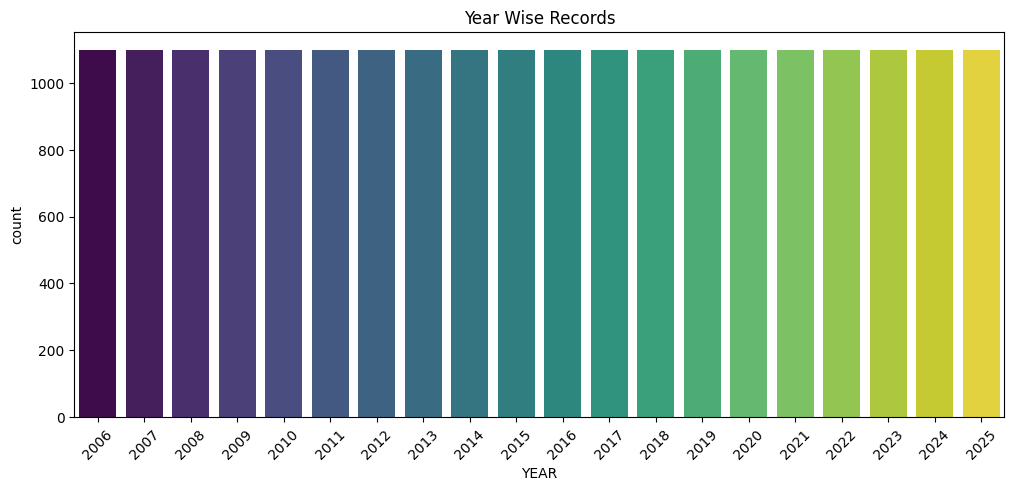

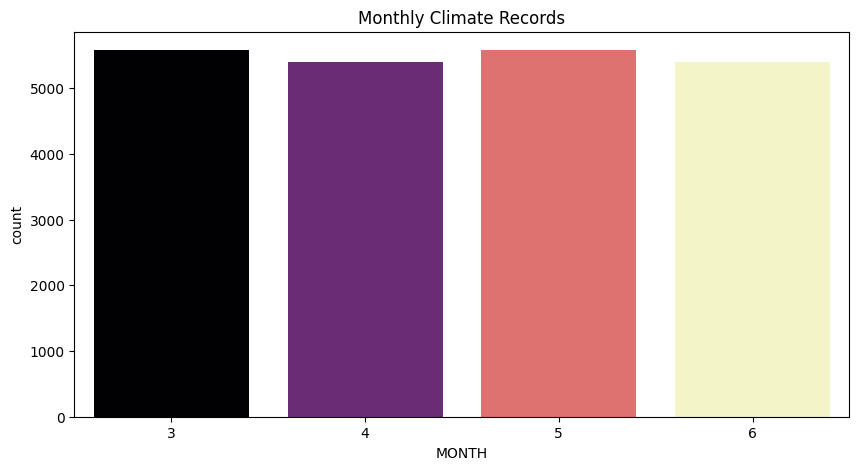

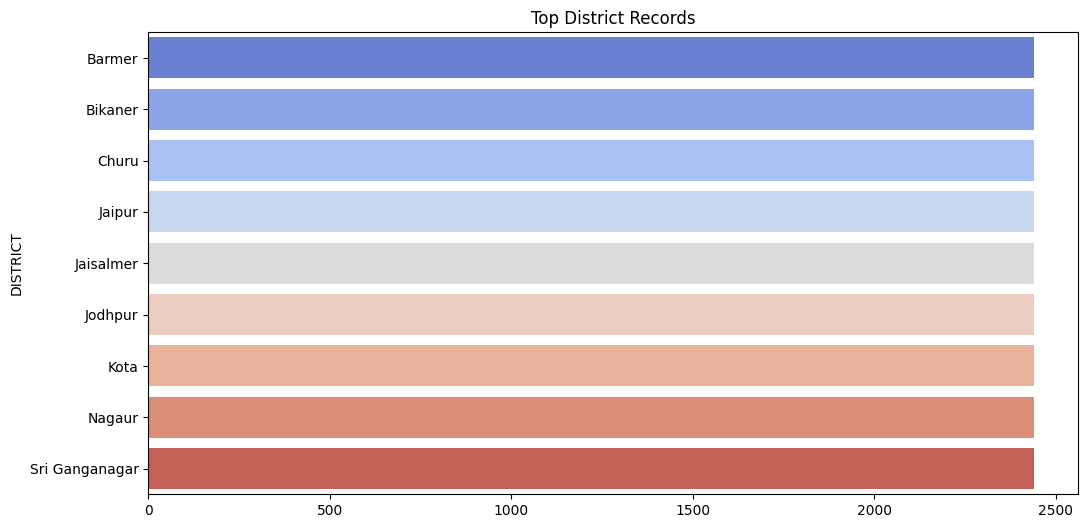

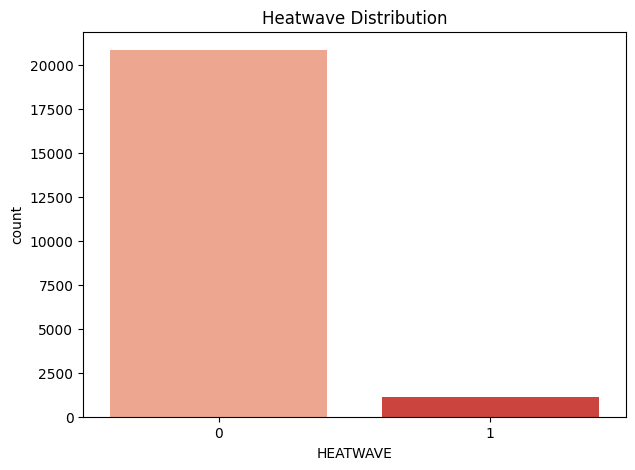

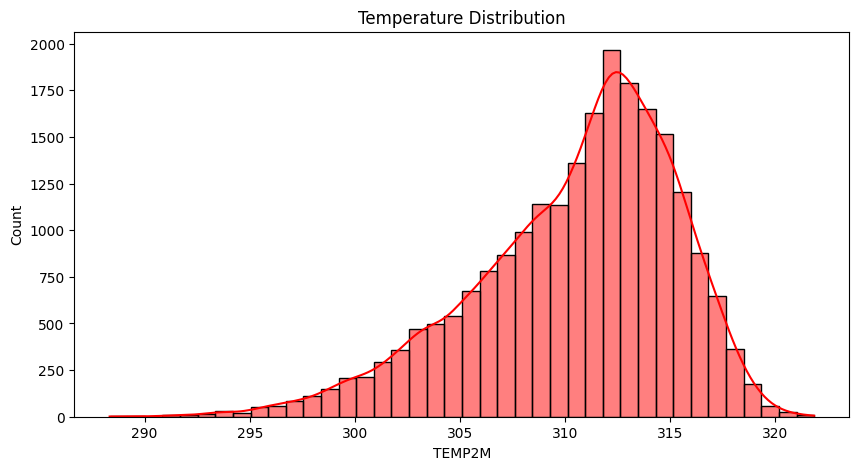

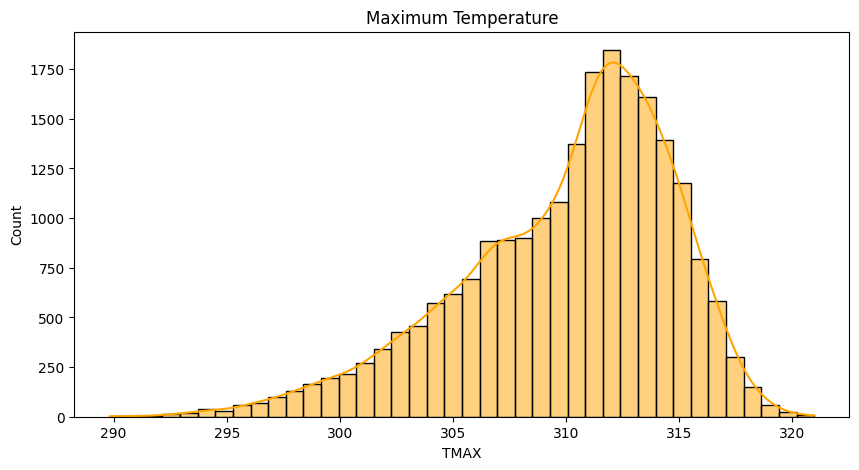

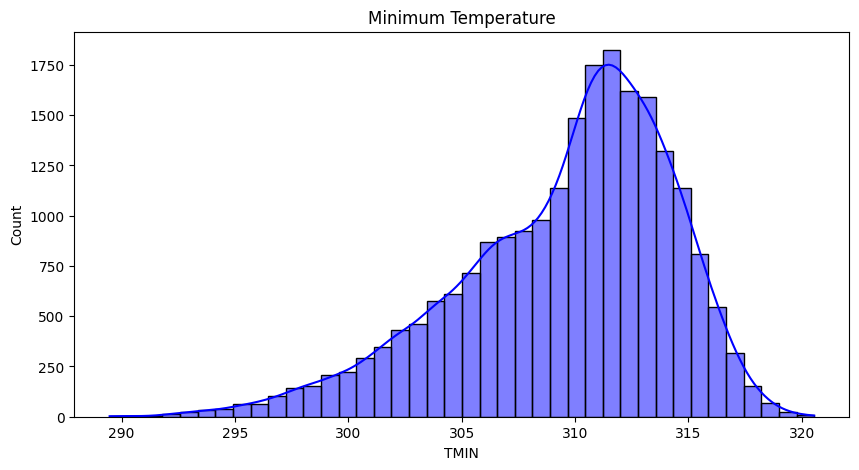

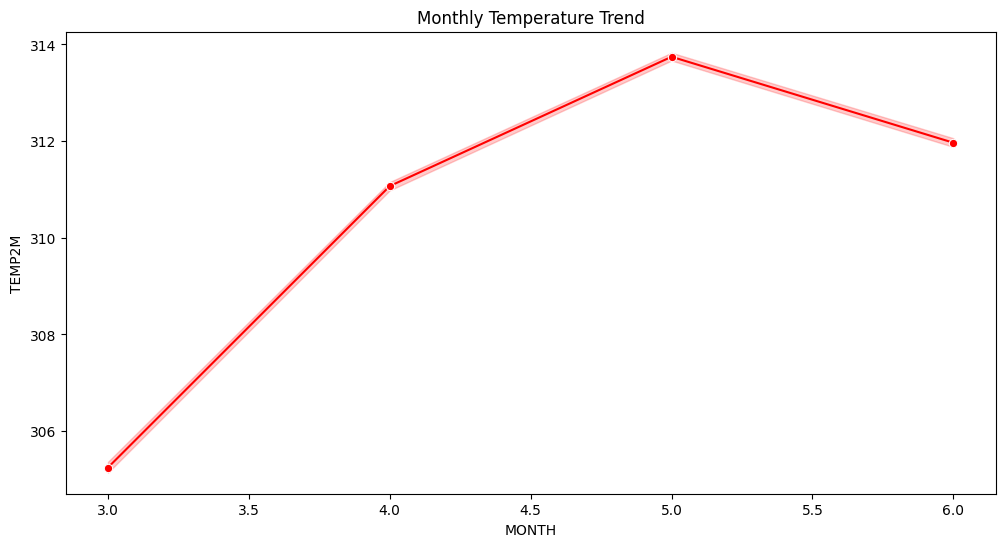

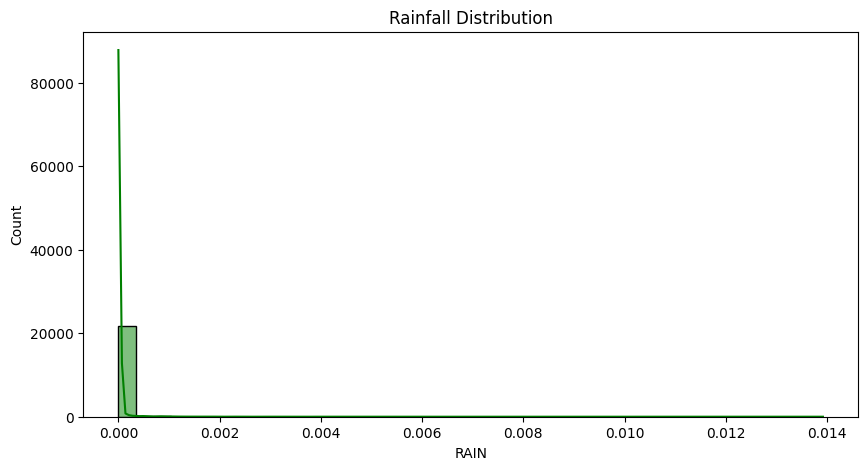

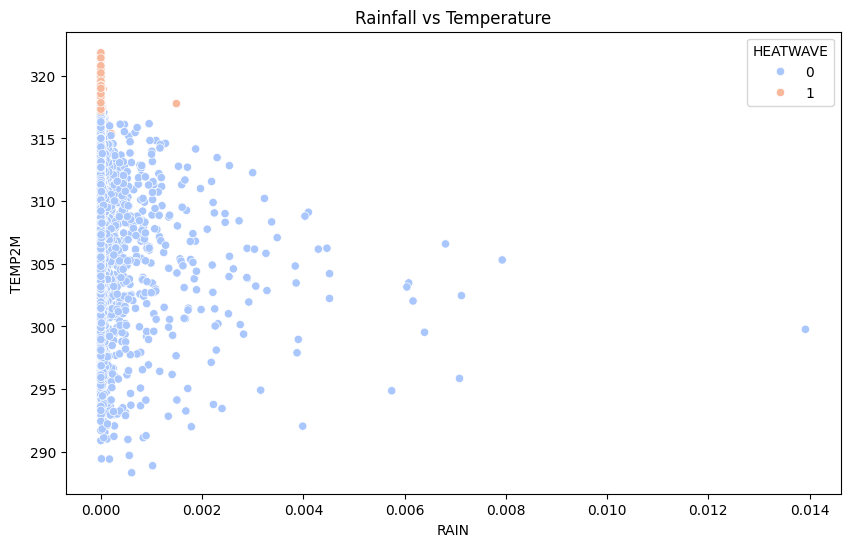

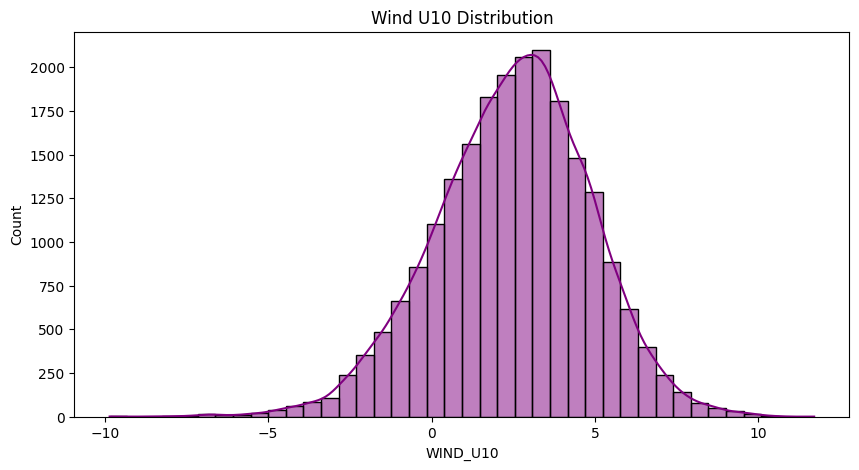

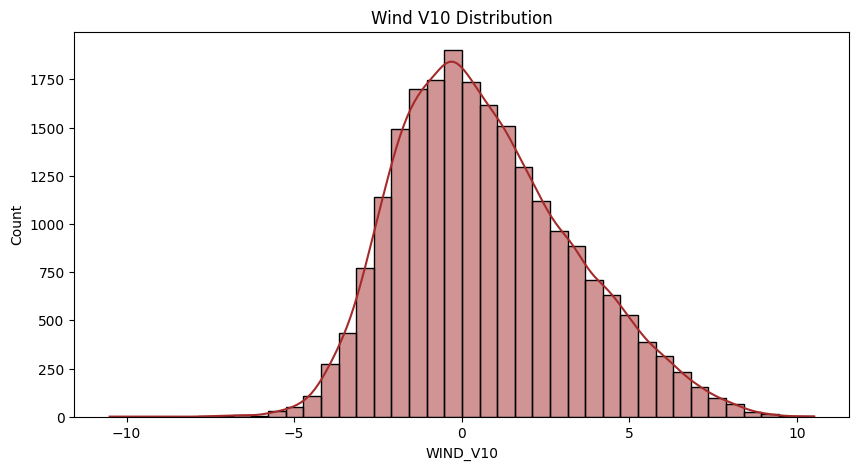

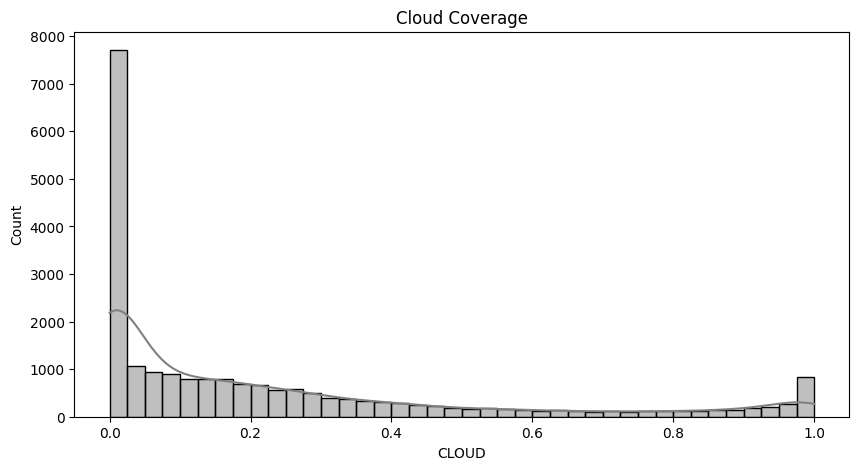

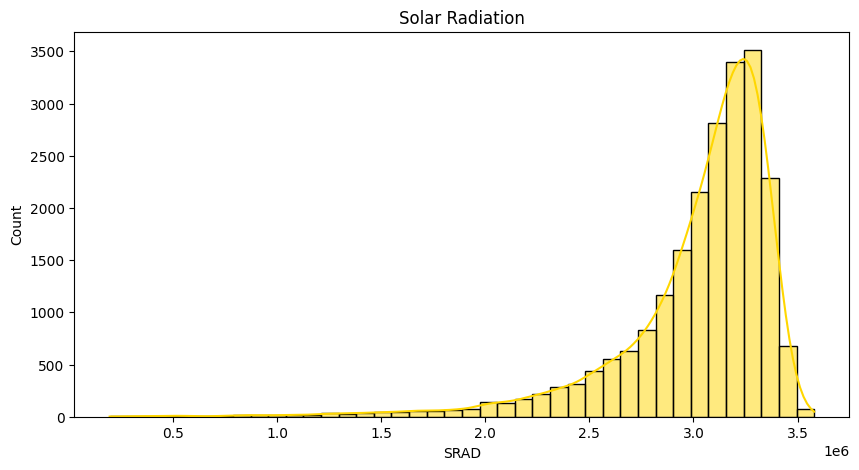

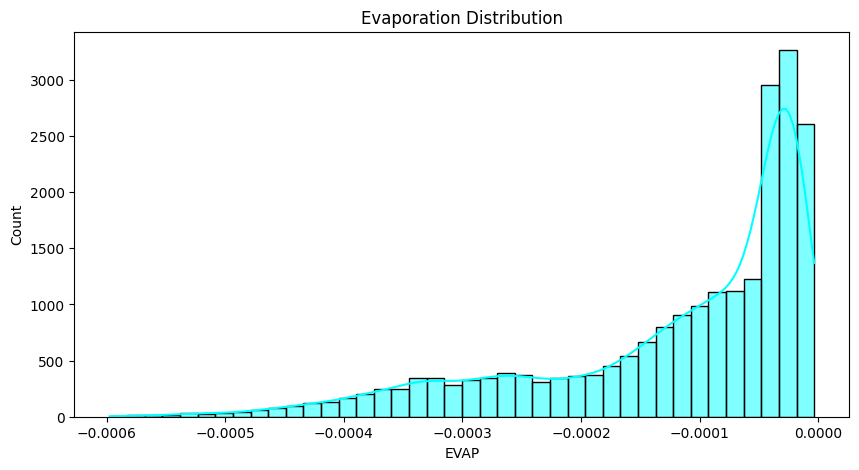

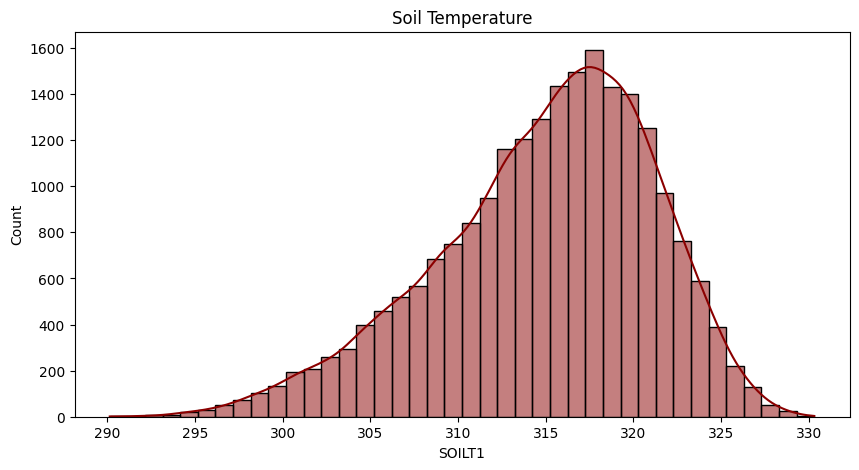

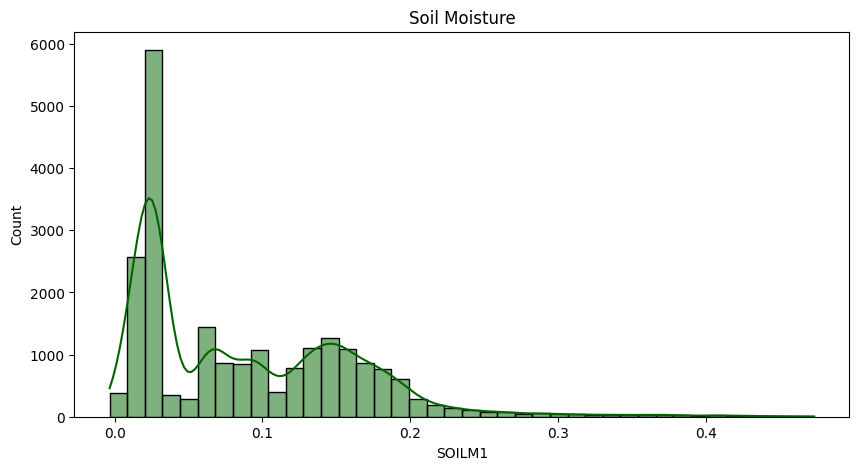

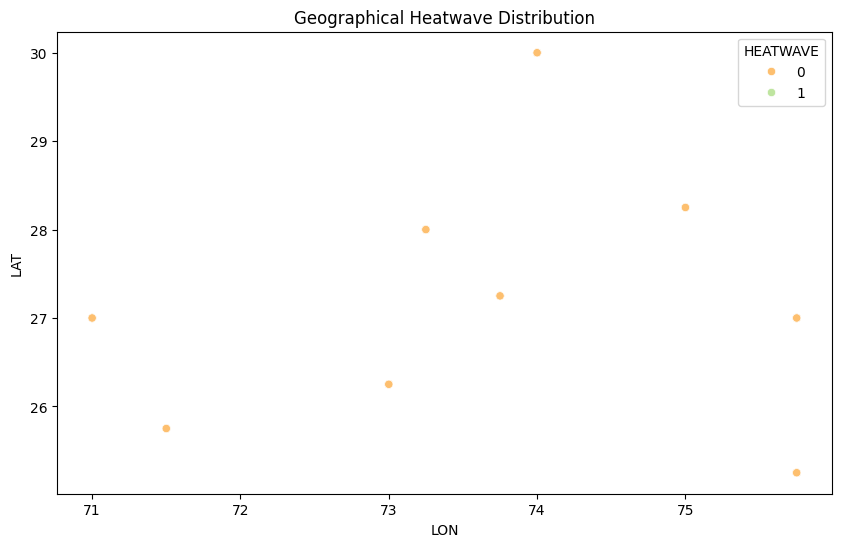

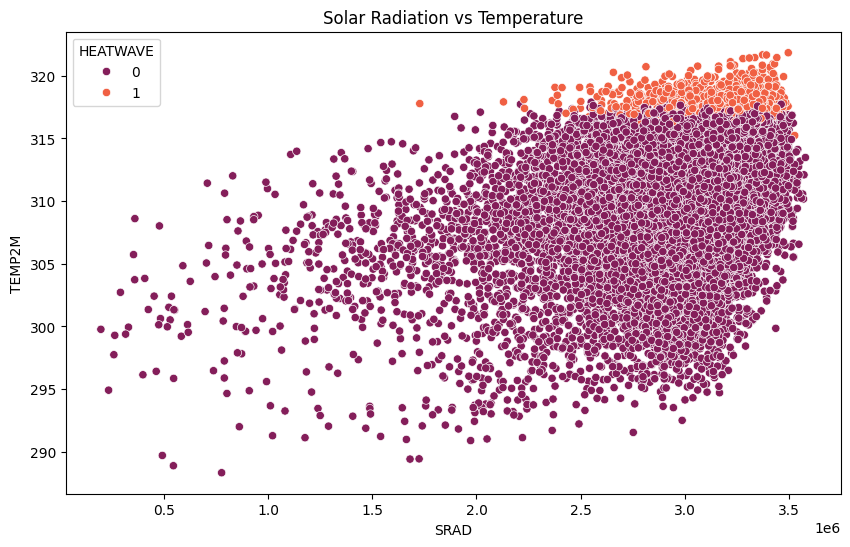

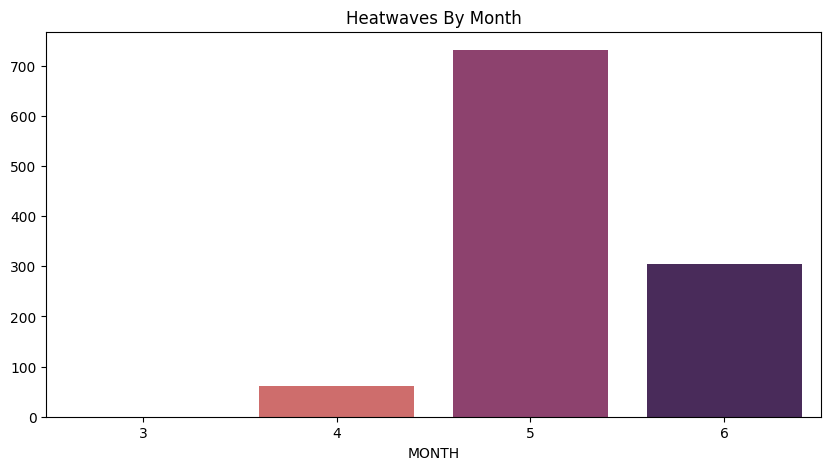

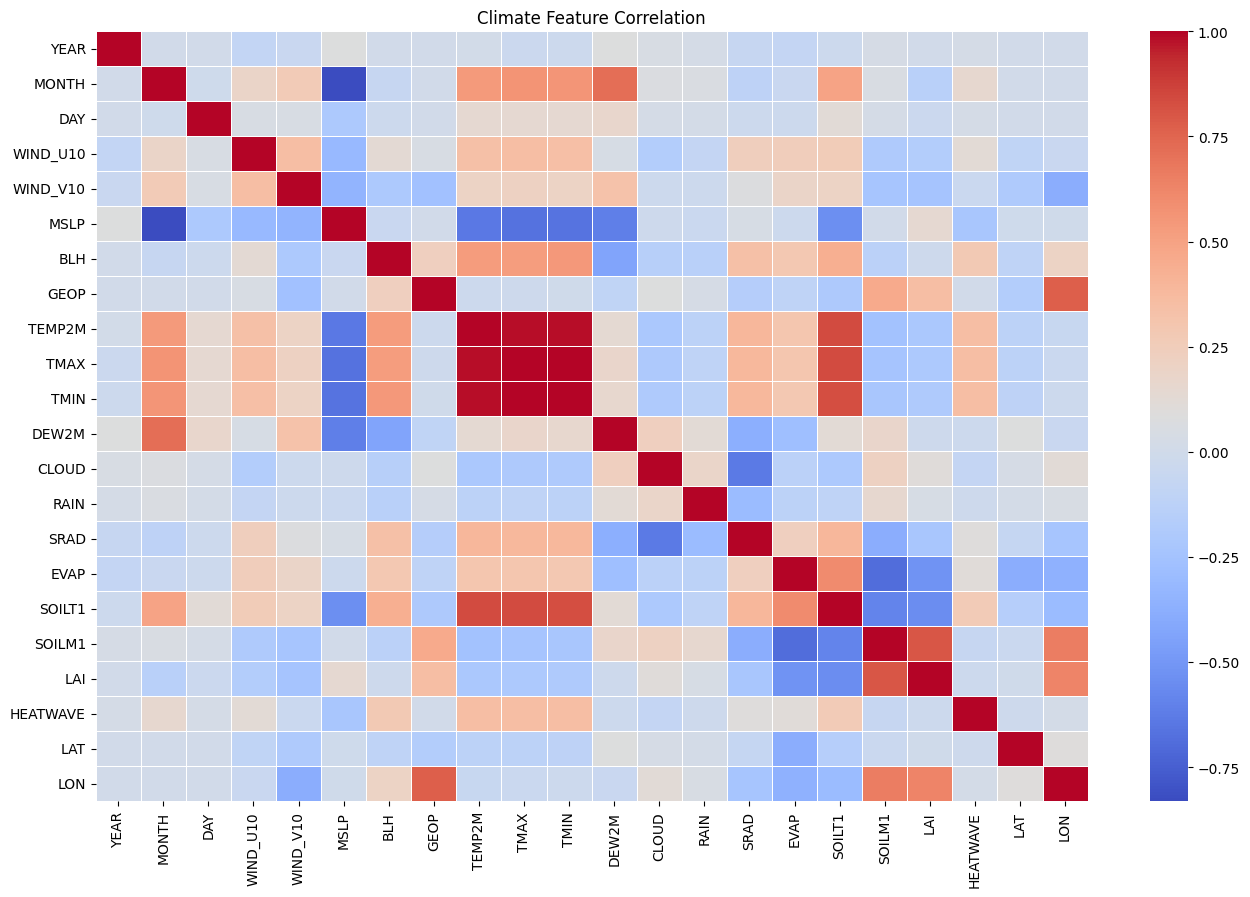

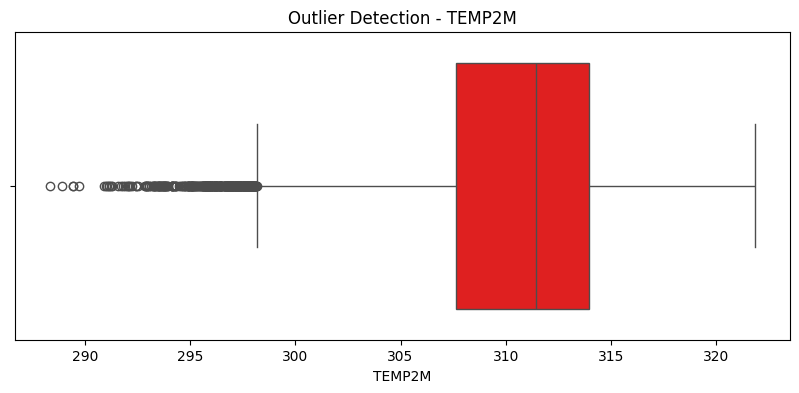

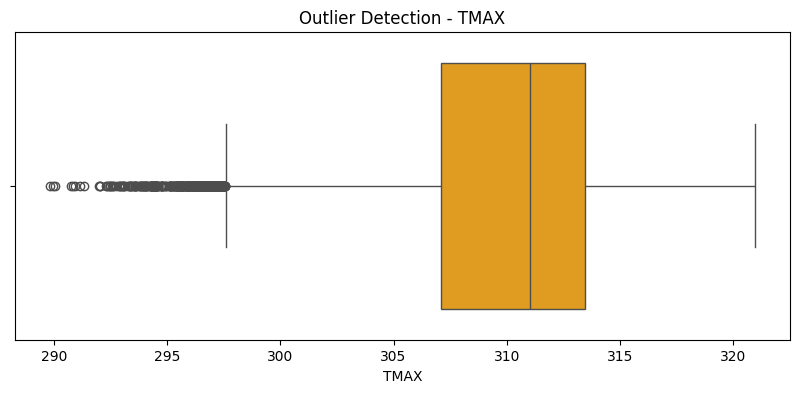

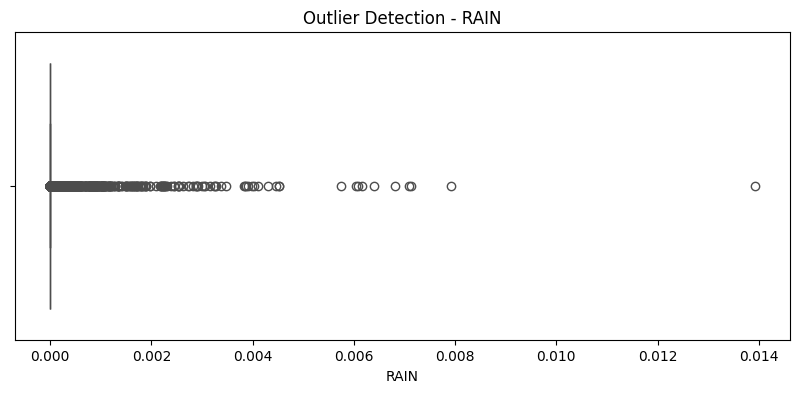

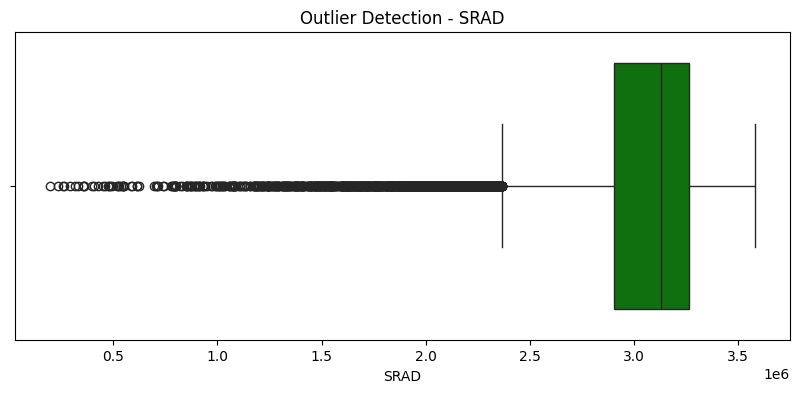

Climate Heatwave Visualization Completed Successfully!


In [10]:
# ============================================================
# 1. YEAR DISTRIBUTION
# ============================================================


plt.figure(figsize=(12,5))


sns.countplot(

data=df,

x="YEAR",

hue="YEAR",

palette="viridis",

legend=False

)


plt.title(
"Year Wise Records"
)


plt.xticks(rotation=45)


plt.show()









# ============================================================
# 2. MONTH DISTRIBUTION
# ============================================================


plt.figure(figsize=(10,5))


sns.countplot(

data=df,

x="MONTH",

hue="MONTH",

palette="magma",

legend=False

)



plt.title(
"Monthly Climate Records"
)


plt.show()









# ============================================================
# 3. DISTRICT ANALYSIS
# ============================================================


district=df["DISTRICT"].value_counts().head(20)


plt.figure(figsize=(12,6))


sns.barplot(

x=district.values,

y=district.index,

hue=district.index,

palette="coolwarm",

legend=False

)


plt.title(
"Top District Records"
)


plt.show()







# ============================================================
# 4. HEATWAVE DISTRIBUTION
# ============================================================


plt.figure(figsize=(7,5))


sns.countplot(

data=df,

x="HEATWAVE",

hue="HEATWAVE",

palette="Reds",

legend=False

)


plt.title(
"Heatwave Distribution"
)


plt.show()









# ============================================================
# 5. TEMPERATURE 2M
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["TEMP2M"],

bins=40,

kde=True,

color="red"

)


plt.title(
"Temperature Distribution"
)


plt.show()







# ============================================================
# 6. MAX TEMPERATURE
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["TMAX"],

bins=40,

kde=True,

color="orange"

)


plt.title(
"Maximum Temperature"
)


plt.show()








# ============================================================
# 7. MIN TEMPERATURE
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["TMIN"],

bins=40,

kde=True,

color="blue"

)


plt.title(
"Minimum Temperature"
)


plt.show()









# ============================================================
# 8. TEMPERATURE BY MONTH
# ============================================================


plt.figure(figsize=(12,6))


sns.lineplot(

data=df,

x="MONTH",

y="TEMP2M",

marker="o",

color="red"

)



plt.title(
"Monthly Temperature Trend"
)


plt.show()







# ============================================================
# 9. RAIN DISTRIBUTION
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["RAIN"],

bins=40,

kde=True,

color="green"

)



plt.title(
"Rainfall Distribution"
)


plt.show()








# ============================================================
# 10. RAIN VS TEMPERATURE
# ============================================================


plt.figure(figsize=(10,6))


sns.scatterplot(

data=df,

x="RAIN",

y="TEMP2M",

hue="HEATWAVE",

palette="coolwarm"

)



plt.title(
"Rainfall vs Temperature"
)



plt.show()








# ============================================================
# 11. WIND SPEED FEATURES
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["WIND_U10"],

bins=40,

kde=True,

color="purple"

)


plt.title(
"Wind U10 Distribution"
)


plt.show()








plt.figure(figsize=(10,5))


sns.histplot(

df["WIND_V10"],

bins=40,

kde=True,

color="brown"

)


plt.title(
"Wind V10 Distribution"
)


plt.show()









# ============================================================
# 12. CLOUD COVER
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["CLOUD"],

bins=40,

kde=True,

color="gray"

)


plt.title(
"Cloud Coverage"
)


plt.show()








# ============================================================
# 13. SOLAR RADIATION
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["SRAD"],

bins=40,

kde=True,

color="gold"

)



plt.title(
"Solar Radiation"
)


plt.show()









# ============================================================
# 14. EVAPORATION
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["EVAP"],

bins=40,

kde=True,

color="cyan"

)


plt.title(
"Evaporation Distribution"
)


plt.show()








# ============================================================
# 15. SOIL TEMPERATURE
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["SOILT1"],

bins=40,

kde=True,

color="darkred"

)


plt.title(
"Soil Temperature"
)


plt.show()







# ============================================================
# 16. SOIL MOISTURE
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["SOILM1"],

bins=40,

kde=True,

color="darkgreen"

)



plt.title(
"Soil Moisture"
)


plt.show()









# ============================================================
# 17. LATITUDE LONGITUDE MAP
# ============================================================


plt.figure(figsize=(10,6))


sns.scatterplot(

data=df,

x="LON",

y="LAT",

hue="HEATWAVE",

palette="Spectral"

)


plt.title(
"Geographical Heatwave Distribution"
)


plt.show()








# ============================================================
# 18. TEMPERATURE VS SOLAR RADIATION
# ============================================================


plt.figure(figsize=(10,6))


sns.scatterplot(

data=df,

x="SRAD",

y="TEMP2M",

hue="HEATWAVE",

palette="rocket"

)



plt.title(
"Solar Radiation vs Temperature"
)


plt.show()









# ============================================================
# 19. HEATWAVE BY MONTH
# ============================================================


heat_month=df.groupby("MONTH")["HEATWAVE"].sum()


plt.figure(figsize=(10,5))


sns.barplot(

x=heat_month.index,

y=heat_month.values,

hue=heat_month.index,

palette="flare",

legend=False

)



plt.title(
"Heatwaves By Month"
)


plt.show()









# ============================================================
# 20. CORRELATION HEATMAP
# ============================================================


numeric=df.select_dtypes(
include=np.number
)



plt.figure(figsize=(16,10))


sns.heatmap(

numeric.corr(),

cmap="coolwarm",

linewidth=0.5

)



plt.title(
"Climate Feature Correlation"
)


plt.show()









# ============================================================
# 21. OUTLIER DETECTION
# ============================================================


features=[

"TEMP2M",

"TMAX",

"RAIN",

"SRAD"

]


colors=[

"red",

"orange",

"blue",

"green"

]



for feature,color in zip(features,colors):


    plt.figure(figsize=(10,4))


    sns.boxplot(

    x=df[feature],

    color=color

    )



    plt.title(
    f"Outlier Detection - {feature}"
    )



    plt.show()







print(
"Climate Heatwave Visualization Completed Successfully!"
)

## Features Engineering

HEATWAVE
0    20862
1     1098
Name: count, dtype: int64

Logistic Regression
Accuracy: 0.9834
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      4172
           1       0.75      1.00      0.86       220

    accuracy                           0.98      4392
   macro avg       0.88      0.99      0.92      4392
weighted avg       0.99      0.98      0.98      4392


Decision Tree
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4172
           1       1.00      1.00      1.00       220

    accuracy                           1.00      4392
   macro avg       1.00      1.00      1.00      4392
weighted avg       1.00      1.00      1.00      4392


Random Forest
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4172
           1       1.00      1.00      1.00       220

    accuracy                 

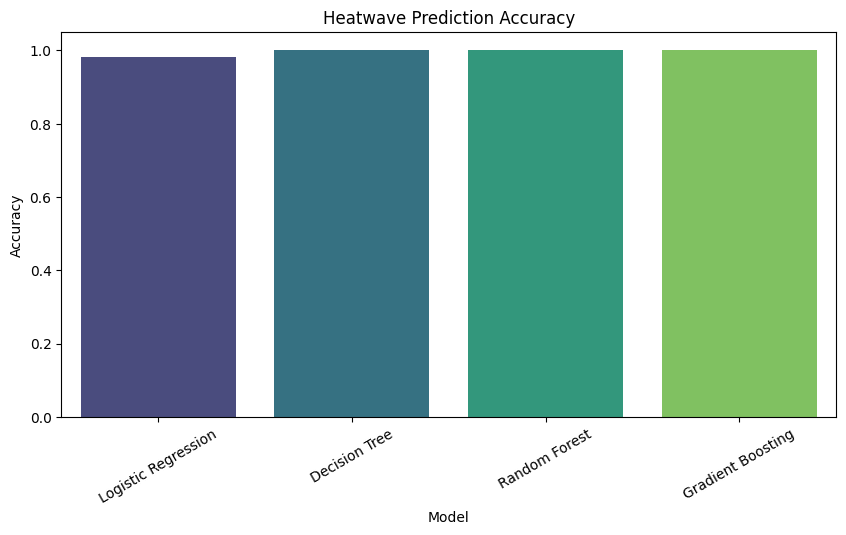

BEST MODEL: Decision Tree


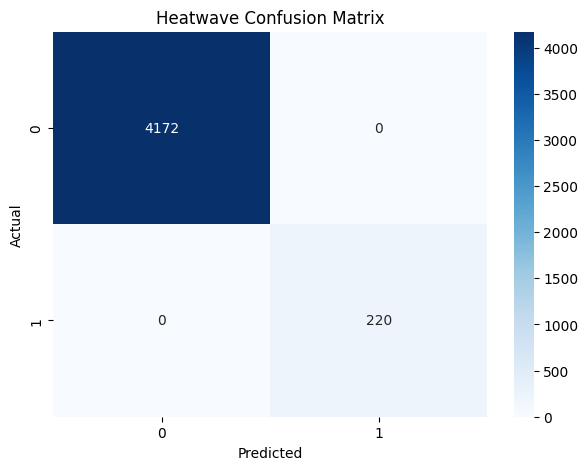

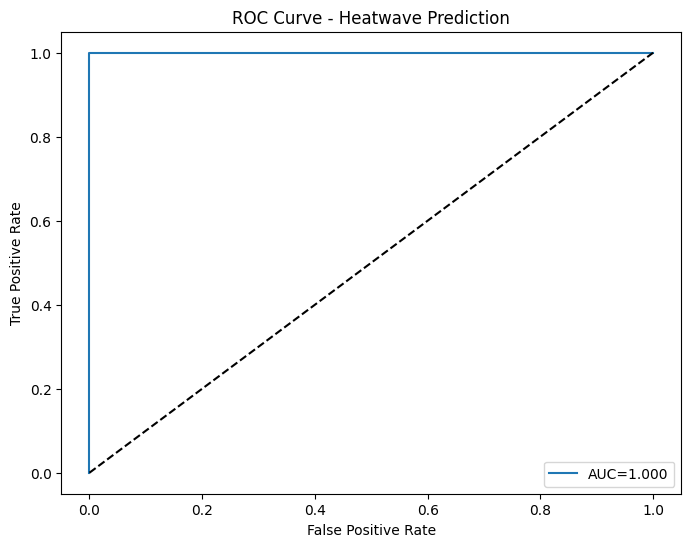

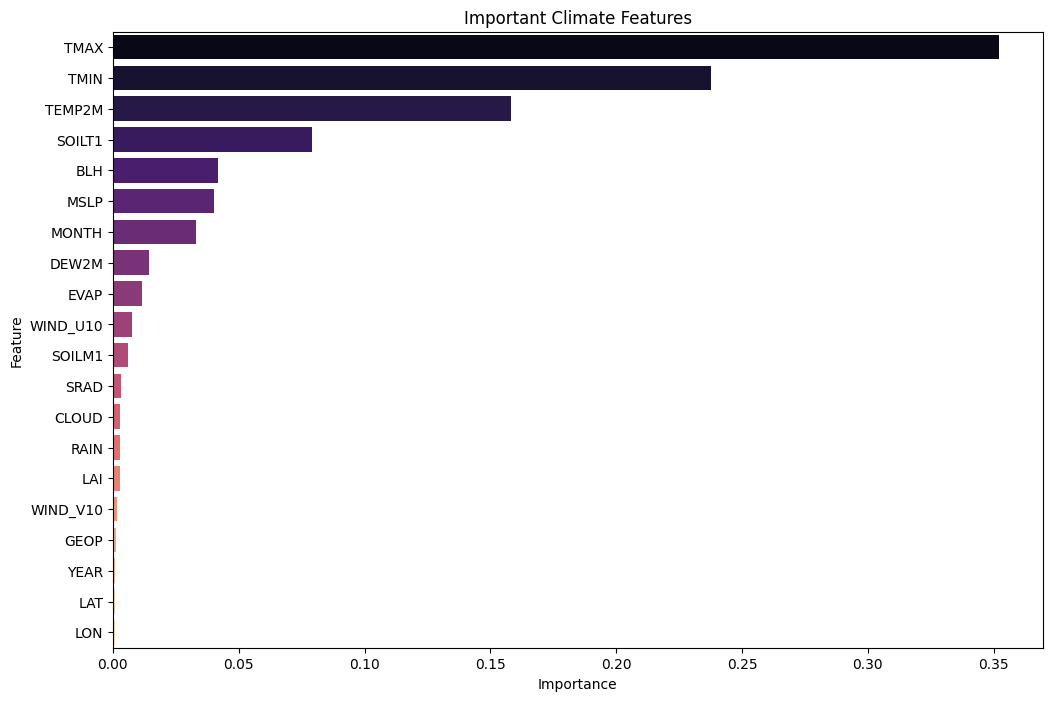


FINAL RESULTS
Logistic Regression : 0.9834
Decision Tree : 1.0
Random Forest : 1.0
Gradient Boosting : 1.0
BEST MODEL: Decision Tree
BEST ACCURACY: 1.0


In [11]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer


from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)


from sklearn.metrics import (

    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score

)

# ============================================================
# TARGET
# ============================================================

target="HEATWAVE"


X=df.drop(
    target,
    axis=1
)


y=df[target]



print(
    y.value_counts()
)








# ============================================================
# REMOVE POSSIBLE LEAKAGE
# ============================================================

# Date/location identifiers are not leakage but can overfit


drop_cols=[

]


X=X.drop(
    columns=drop_cols,
    errors="ignore"
)









# ============================================================
# TRAIN TEST SPLIT BEFORE PROCESSING
# ============================================================


X_train,X_test,y_train,y_test=train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)









# ============================================================
# COLUMN TYPES
# ============================================================

numeric_cols=X.select_dtypes(
    include=np.number
).columns



categorical_cols=X.select_dtypes(
    include="object"
).columns









# ============================================================
# NUMERIC PIPELINE
# ============================================================

numeric_pipeline=Pipeline(

steps=[



(

"imputer",

SimpleImputer(
strategy="median"
)

),



(

"scaler",

StandardScaler()

)



]

)









# ============================================================
# CATEGORY PIPELINE
# ============================================================

categorical_pipeline=Pipeline(

steps=[



(

"imputer",

SimpleImputer(
strategy="most_frequent"
)

),



(

"encoder",

OneHotEncoder(
handle_unknown="ignore"
)

)



]

)









# ============================================================
# PREPROCESSING
# ============================================================


preprocessor=ColumnTransformer(

transformers=[



(

"num",

numeric_pipeline,

numeric_cols

),




(

"cat",

categorical_pipeline,

categorical_cols

)



]

)









# ============================================================
# MODELS
# ============================================================


models={



"Logistic Regression":

LogisticRegression(

max_iter=1000,

class_weight="balanced"

),





"Decision Tree":

DecisionTreeClassifier(

random_state=42,

class_weight="balanced"

),






"Random Forest":

RandomForestClassifier(

n_estimators=200,

random_state=42,

class_weight="balanced",

n_jobs=-1

),






"Gradient Boosting":

GradientBoostingClassifier(

random_state=42

)



}








results={}

trained={}









# ============================================================
# MODEL TRAINING
# ============================================================


for name,model in models.items():


    print("\n===================")

    print(name)

    print("===================")





    pipe=Pipeline(

    steps=[




    (

    "preprocessor",

    preprocessor

    ),




    (

    "model",

    model

    )




    ]

    )








    pipe.fit(

        X_train,

        y_train

    )








    pred=pipe.predict(

        X_test

    )








    acc=accuracy_score(

        y_test,

        pred

    )






    results[name]=acc


    trained[name]=pipe









    print(

        "Accuracy:",

        round(acc,4)

    )





    print(

        classification_report(

        y_test,

        pred

        )

    )











# ============================================================
# ACCURACY GRAPH
# ============================================================


accuracy_df=pd.DataFrame({

"Model":list(results.keys()),

"Accuracy":list(results.values())

})





plt.figure(figsize=(10,5))


sns.barplot(

data=accuracy_df,

x="Model",

y="Accuracy",

hue="Model",

palette="viridis",

legend=False

)



plt.title(
"Heatwave Prediction Accuracy"
)


plt.xticks(rotation=30)


plt.show()









# ============================================================
# BEST MODEL
# ============================================================


best_name=max(

results,

key=results.get

)



best_model=trained[
best_name
]



print(

"BEST MODEL:",

best_name

)









# ============================================================
# CONFUSION MATRIX
# ============================================================


best_pred=best_model.predict(

X_test

)





plt.figure(figsize=(7,5))



sns.heatmap(

confusion_matrix(

y_test,

best_pred

),

annot=True,

fmt="d",

cmap="Blues"

)



plt.title(
"Heatwave Confusion Matrix"
)



plt.xlabel(
"Predicted"
)


plt.ylabel(
"Actual"
)


plt.show()










# ============================================================
# ROC CURVE
# ============================================================


prob=best_model.predict_proba(

X_test

)[:,1]






fpr,tpr,_=roc_curve(

y_test,

prob

)




auc=roc_auc_score(

y_test,

prob

)







plt.figure(figsize=(8,6))


plt.plot(

fpr,

tpr,

label=f"AUC={auc:.3f}"

)




plt.plot(

[0,1],

[0,1],

"k--"

)




plt.xlabel(
"False Positive Rate"
)



plt.ylabel(
"True Positive Rate"
)



plt.title(
"ROC Curve - Heatwave Prediction"
)



plt.legend()


plt.show()










# ============================================================
# FEATURE IMPORTANCE
# ============================================================


rf=trained[

"Random Forest"

]




feature_names=(

list(numeric_cols)

+

list(

rf.named_steps["preprocessor"]

.named_transformers_["cat"]

.named_steps["encoder"]

.get_feature_names_out(

categorical_cols

)

)

)







importance=pd.DataFrame({

"Feature":feature_names,


"Importance":

rf.named_steps["model"]

.feature_importances_

})








importance=importance.sort_values(

"Importance",

ascending=False

)








plt.figure(figsize=(12,8))


sns.barplot(

data=importance.head(20),

x="Importance",

y="Feature",

hue="Feature",

palette="magma",

legend=False

)




plt.title(
"Important Climate Features"
)



plt.show()










# ============================================================
# FINAL RESULTS
# ============================================================


print("\nFINAL RESULTS")

print("===================")



for model,score in results.items():


    print(

        model,

        ":",

        round(score,4)

    )




print("===================")



print(

"BEST MODEL:",

best_name

)



print(

"BEST ACCURACY:",

round(max(results.values()),4)

)

## Thanks.............Please Upvote